# Flow of a Stokes fluid in a corrugated channel

$$
\mathbb{S}
\begin{cases}
\Omega = \left\{(x, y)~:~0<x<L_x~,~\epsilon^-\sin\left(\frac{2\pi n^-x}{L_x}\right)<y<L_y+\epsilon^+\sin\left(\frac{2\pi n^+x}{L_x}\right) \right\} \\
\partial\Omega_{\text{lower}} = \left\{(x, y)~:~ y=\epsilon^-\sin\left(\frac{2\pi n^-x}{L_x}\right) \right\} \\
\partial\Omega_{\text{upper}} = \{(x, y)~:~y=L_y + \epsilon^+\sin\left(\frac{2\pi n^+x}{L_x}\right) \} \\
\partial\Omega_{\text{left}} = \{(x, y)~:~x=0 \} \\
\partial\Omega_{\text{right}} = \{(x, y)~:~x=L_x \} \\
\textbf{u}_{\text{E}}\vert_{\partial\Omega_{\text{lower}}\cup\partial\Omega_{\text{upper}}}=\textbf{0} & \text{no-flow on upper and lower boundaries} \\
\textbf{u}_{\text{E}}(x=0,y)=\textbf{u}_{\text{in}} & \text{inflow on left boundary} \\
\boldsymbol{\tau}_{\text{N}}(x=L_x,y)=\textbf{0} & \text{outflow on right boundary} \\
\end{cases}
$$

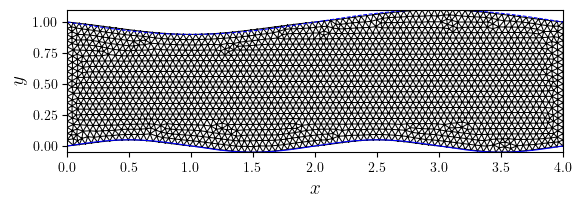

In [6]:
import numpy as np
from ufl import grad
from lucifex.mesh import mesh_from_boundaries
from lucifex.fem import Function, Constant
from lucifex.solver import bvp, BoundaryConditions, OptionsPETSc
from lucifex.utils import get_component_fem_functions, as_spatial_marker
from lucifex.viz import plot_colormap, plot_line, plot_mesh, plot_line, plot_contours, save_figure
from lucifex.pde.stokes import stokes_incompressible
from lucifex.pde.streamfunction_vorticity import streamfunction_from_velocity
from lucifex.mesh import mesh_from_boundaries

h = 0.05
Lx = 4.0
Ly = 1.0
eps_lower = 0.05
eps_upper = 0.1
n_lower = 4
n_upper = -2

lower = lambda x: eps_lower * np.sin(np.pi * n_lower * x / Lx)
upper = lambda x: eps_upper * np.sin(np.pi * n_upper * x / Lx)
boundary = {
        "right": lambda x: x[0] - Lx,
        "upper": lambda x: x[1] - Ly - upper(x[0]),
        "left": lambda x: x[0],
        "lower": lambda x: x[1] - lower(x[0]),
}
dx_bbox = 1e-2
dy_bbox = 1e-2
x_bbox = np.arange(0, Lx + dx_bbox, dx_bbox)
y_bbox = np.arange(-eps_lower, Ly + eps_upper + dy_bbox, dy_bbox)

mesh = mesh_from_boundaries(h, 'triangle')(
    x_bbox, y_bbox, *boundary.values(),
    method='addSpline',
)

fig, ax = plot_mesh(mesh)
plot_line(
    fig, ax, 
    [(x_bbox, lower(x_bbox)), (x_bbox, Ly + upper(x_bbox))], 
    color='blue',
)
save_figure('mesh')(fig)

In [7]:
lower_approx = as_spatial_marker(boundary['lower'], atol=h)
upper_approx = as_spatial_marker(boundary['upper'], atol=h)

mu = Constant(mesh, 1.0, 'mu')
stress = lambda u: mu * grad(u)

u_elem = ('P', 2, 2)
p_elem = ('P', 1)
u_p_elem = [u_elem, p_elem]
up = Function((mesh, u_p_elem), name="up")

uIn_max = 1.0
uIn = lambda x: 4 * uIn_max * x[1] * (Ly - x[1]) / Ly**2
bcs_e = BoundaryConditions(
    ('essential', boundary['left'], (uIn, 0.0), 0),
    ('essential', upper_approx, (0.0, 0.0), 0),
    ('essential', lower_approx, (0.0, 0.0), 0),
)
bcs_n = BoundaryConditions(
    ('natural', boundary['right'], (0.0, 0.0), 1),
)

petsc = OptionsPETSc(pc_type='lu', pc_factor_mat_solver_type='mumps')
up_solver = bvp(stokes_incompressible, bcs_e, petsc)(up, stress, bcs=bcs_n)
up_solver.solve()

u, p = up.split(('u', 'p'), collapse=True)

psi = Function((mesh, 'P', 1), name="psi")
bcs_psi = BoundaryConditions(
    ('dirichlet', upper_approx, 0.0),
    ('dirichlet', lower_approx, 0.0),
)
psi_solver = bvp(streamfunction_from_velocity, bcs_psi)(psi, u)
psi_solver.solve()

ux, uy = get_component_fem_functions(('P', 1), u, names=('ux', 'uy'))

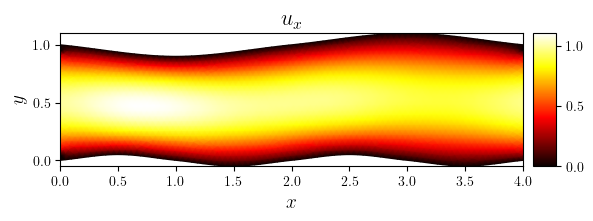

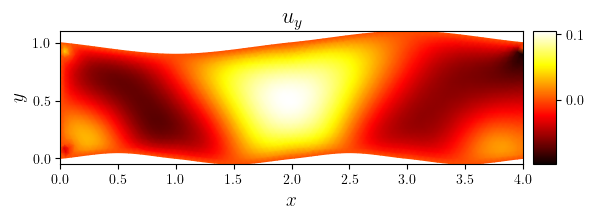

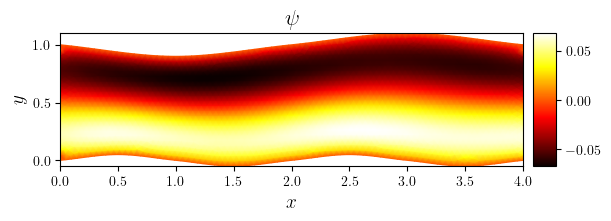

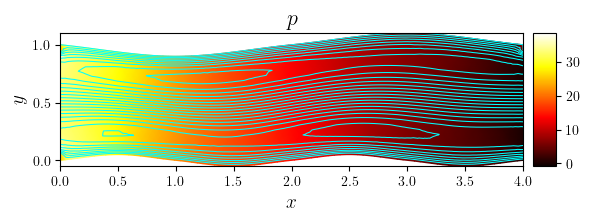

In [8]:
fig, ax = plot_colormap(ux, title=f'${u.name}_x$')
save_figure('ux(x,y)')(fig)

fig, ax = plot_colormap(uy, title=f'${u.name}_y$')
save_figure('uy(x,y)')(fig)

fig, ax = plot_colormap(psi, title=f'$\psi$')
save_figure('psi(x,y)')(fig)

fig, ax = plot_colormap(p, title=f'$p$')
plot_contours(fig, ax, psi, colors='cyan', levels=20)
save_figure('p(x,y)_streamlines', thumbnail=True)(fig)